In [1]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from utils.dataset.config import DatasetPath
from utils.dataset.clickstream_generator import generate_clickstream

[INFO] Font applied: NanumGothic


# Dataset Path

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(root_dir=dataset_dir, dataset_name="fashion")

# Clickstream Dataset
- 가상의 클릭 스트림 데이터 생성

In [3]:
generate_clickstream(
    user_metadata_path=paths.user_metadata_path,  # 유저 메타데이터 parquet 파일
    item_metadata_path=paths.item_metadata_path,  # 아이템 메타데이터 parquet 파일
    save_path=paths.user_logs_path,  # 생성된 클릭스트림 parquet 파일 저장 경로
    users_per_chunk=1000,  # 유저별 로그를 나누어 저장할 단위 (1,000명씩 저장)
    n_sessions_per_user=5,  # 각 유저가 가질 세션 개수
    actions=["click", "wishlist", "cart", "purchase"],  # 행동 유형
    action_weights=[0.8, 0.1, 0.05, 0.05],  # 행동별 확률
    similarity_keys=[
        "gender",
        "age_group",
        "season",
        "master_category",
        "sub_category",
        "article_type",
        "usage",
    ],  # 유사 아이템을 묶을 기준
    start_date=datetime(2025, 10, 1),  # 클릭 로그 시작 시점
    seed=42,  # 랜덤 시드 (재현성)
)

# Load Dataset

In [4]:
df = pd.read_parquet(paths.user_logs_path)

In [5]:
df.shape

(218501, 21)

In [6]:
df.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,2676,2025-10-21 03:01:00,click,46,Women,Baggit Women Fighter Mayur Black Belt,Baggit,525.0,525.0,...,Black,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p>A belt is an essential detail to complete y...
1,1,2619,2025-10-21 03:02:00,click,46,Women,Baggit Women Blue Spirit Dum Belt,Baggit,575.0,575.0,...,Blue,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note </strong><br />A summer ...
2,1,1617,2025-10-21 03:05:00,click,46,Women,Baggit Women Flora Moly Red Belt,Baggit,500.0,500.0,...,Red,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note</strong><br /> A belt is...
3,1,8224,2025-10-21 03:04:00,click,46,Women,Baggit Women Brown Xylo Taj Belt,Baggit,575.0,575.0,...,Brown,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note </strong><br />A summer ...
4,1,1114,2025-10-21 03:17:00,click,46,Women,Wills Lifestyle Women Leather Blue Belt,Wills Lifestyle,999.0,649.0,...,Blue,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,"<div><span style=""font-family: tahoma, arial, ..."


# EDA

## Item Frequency

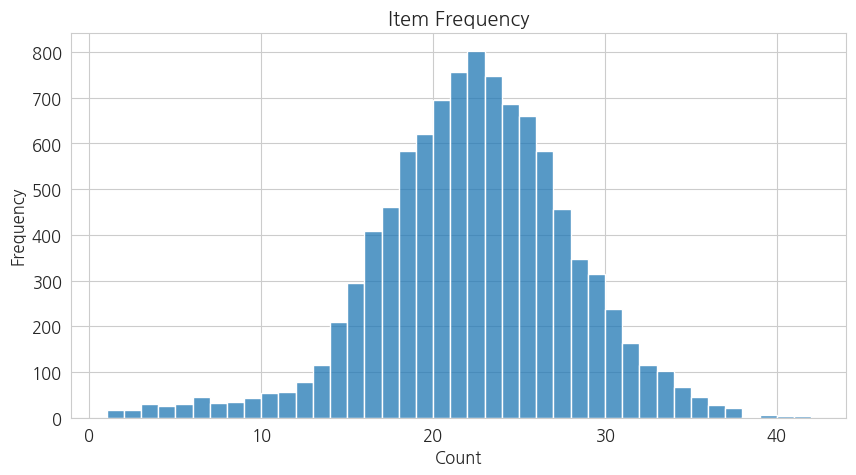

In [7]:
# - `item_id`별 등장 횟수를 세어 분포 확인
# - `item_id`별 등장 횟수를 세어 분포 확인
# - 인기 아이템과 Long-tail 아이템을 직관적으로 볼 수 있음
plt.figure(figsize=(10, 5), dpi=100)
sns.histplot(x=df["item_id"].value_counts(), binwidth=1)
plt.title("Item Frequency")
plt.xlabel("Count")  # 특정 아이템이 등장한 횟수
plt.ylabel("Frequency")  # 등장 횟수별 아이템의 개수
plt.show()